In [1]:
import os
#import yfinance as yf
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import boto3
import os

s3 = boto3.client(
    "s3",
    # aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    # aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    # Endpoint jest potrzebny dlatego że używamy chmury innej niż AWS 
    # endpoint_url=os.getenv("AWS_ENDPOINT_URL_S3"), 
    # Gdybyśmy używali AWS to musielibyśmy natomiast podać region
    #region_name='eu-central-1'
)

In [3]:
BUCKET_NAME = "gotoitpiotrk"

In [12]:
import s3fs
#print(s3fs.__version__)

In [13]:
# pliki csv z danymi ręcznie skopiowałem do mojej przestrzeni w DigitalOcean
#h_marathon_data
import pandas as pd

paginator = s3.get_paginator("list_objects_v2")
data = []
for page in paginator.paginate(Bucket=BUCKET_NAME, Prefix="h_marathon_data/"):
    for obj in page["Contents"]:
        if "2023" in obj["Key"]:
            data.append(pd.read_csv(f"s3://{BUCKET_NAME}/{obj['Key']}", sep=';'))

df2023 = pd.concat(data)

paginator = s3.get_paginator("list_objects_v2")
data = []
for page in paginator.paginate(Bucket=BUCKET_NAME, Prefix="h_marathon_data/"):
    for obj in page["Contents"]:
        if "2024" in obj["Key"]:
            data.append(pd.read_csv(f"s3://{BUCKET_NAME}/{obj['Key']}", sep=';'))

df2024 = pd.concat(data)
df2023.shape

(8950, 27)

In [ ]:
df2023.columns.tolist()

In [ ]:
df2024.columns.tolist()

In [14]:
df2024.shape

(13007, 27)

In [15]:
df2023["Wiek_w_latach"] = 2023 - df2023["Rocznik"]
df2024["Wiek_w_latach"] = 2024 - df2024["Rocznik"]
df2023.shape

(8950, 28)

In [16]:
df2024.shape

(13007, 28)

In [10]:
df2023.head()

,Miejsce,Numer startowy,Imię,Nazwisko,Miasto,Kraj,Drużyna,Płeć,Płeć Miejsce,Kategoria wiekowa,...,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo,Wiek_w_latach
0,1.0,1787,TOMASZ,GRYCKO,NaN,POL,UKS BLIZA WŁADYSŁAWOWO,M,1.0,M30,...,00:44:47,1.0,3.106667,01:01:43,1.0,3.386667,0.031400,01:04:59,3.080509,31.0
1,2.0,3,ARKADIUSZ,GARDZIELEWSKI,WROCŁAW,POL,ARKADIUSZGARDZIELEWSKI.PL,M,2.0,M30,...,00:45:26,2.0,3.143333,01:03:08,2.0,3.540000,0.038000,01:06:23,3.146875,37.0
2,3.0,3832,KRZYSZTOF,HADAS,POZNAŃ,POL,NaN,M,3.0,M20,...,00:47:34,3.0,3.236667,01:05:09,3.0,3.516667,0.024067,01:08:24,3.242475,27.0
3,4.0,416,DAMIAN,DYDUCH,KĘPNO,POL,AZS POLITECHNIKA OPOLSKA,M,4.0,M30,...,00:48:49,5.0,3.330000,01:06:54,4.0,3.616667,0.025467,01:10:16,3.330963,35.0
4,5.0,8476,KAMIL,MAŃKOWSKI,MIRKÓW,POL,PARKRUN WROCŁAW,M,5.0,M20,...,00:49:31,7.0,3.386667,01:07:27,5.0,3.586667,0.023000,01:10:27,3.339654,28.0


In [11]:
df2024.head()

,Miejsce,Numer startowy,Imię,Nazwisko,Miasto,Kraj,Drużyna,Płeć,Płeć Miejsce,Kategoria wiekowa,...,15 km Czas,15 km Miejsce Open,15 km Tempo,20 km Czas,20 km Miejsce Open,20 km Tempo,Tempo Stabilność,Czas,Tempo,Wiek_w_latach
0,1.0,596,NIKODEM,DWORCZAK,KOŚCIAN,POL,NaN,M,1.0,M20,...,00:45:07,2.0,3.083333,01:00:33,1.0,3.086667,0.007267,01:04:03,3.036265,26.0
1,2.0,616,MATEUSZ,KACZOR,RADOM,POL,RLTL OPTIMA RADOM,M,2.0,M20,...,00:45:07,3.0,3.083333,01:00:38,2.0,3.103333,0.008267,01:04:24,3.052856,27.0
2,3.0,154,PATRYK,KOZŁOWSKI,RADOM,POL,RLTL-ZTE-RADOM,M,3.0,M20,...,00:45:07,1.0,3.083333,01:00:59,3.0,3.173333,0.012467,01:04:40,3.065497,26.0
3,4.0,591,DARIUSZ,BORATYŃSKI,WROCŁAW,POL,WOSIEK TEAM AZS AWF WROCŁAW,M,4.0,M20,...,00:47:48,4.0,3.293333,01:05:40,4.0,3.573333,0.028667,01:09:44,3.305681,27.0
4,5.0,521,SZYMON,DOROŻYŃSKI,LUBON,POL,SZYMI TEAM AZS POLITECHNIKA OPOLSKA,M,5.0,M30,...,00:48:09,5.0,3.453333,01:06:05,5.0,3.586667,0.039800,01:10:05,3.322272,32.0


In [17]:
df = pd.concat([df2023, df2024], ignore_index=True)
print(df.shape)

(21957, 28)


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21957 entries, 0 to 21956
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Miejsce                    18450 non-null  float64
 1   Numer startowy             21957 non-null  int64  
 2   Imię                       21957 non-null  object 
 3   Nazwisko                   21957 non-null  object 
 4   Miasto                     17774 non-null  object 
 5   Kraj                       18450 non-null  object 
 6   Drużyna                    8402 non-null   object 
 7   Płeć                       21946 non-null  object 
 8   Płeć Miejsce               18450 non-null  float64
 9   Kategoria wiekowa          21926 non-null  object 
 10  Kategoria wiekowa Miejsce  18430 non-null  float64
 11  Rocznik                    21472 non-null  float64
 12  5 km Czas                  18411 non-null  object 
 13  5 km Miejsce Open          18411 non-null  flo

In [18]:
# Snippet pomocniczy - zmiana czasu na sekundy

def convert_time_to_seconds(time):
    if pd.isnull(time) or time in ['DNS', 'DNF']:
        return None
    time = time.split(':')
    return int(time[0]) * 3600 + int(time[1]) * 60 + int(time[2])

In [19]:
df['Czas'] = df['Czas'].apply(convert_time_to_seconds)

In [20]:
# 
df['Czas'].head()

0    3899.0
1    3983.0
2    4104.0
3    4216.0
4    4227.0
Name: Czas, dtype: float64

In [21]:
df.describe(include="all").T
#Tworzy statystyczne podsumowanie danych numerycznych (domyślnie).
#Dla kolumn liczbowych podaje m.in.:
#count – liczba niepustych wartości, mean – średnia, std – odchylenie standardowe,min, 25%, 50% (mediana), 75%, max.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Miejsce,18450.0,NaN,NaN,NaN,4675.680325,2768.84611,1.0,2307.0,4613.0,6919.0,10302.0
Numer startowy,21957.0,NaN,NaN,NaN,9131.001685,14449.830643,1.0,2994.0,5847.0,8771.0,86990.0
Imię,21957,975,TOMASZ,795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nazwisko,21957,10274,ZAWODNIK,699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Miasto,17774,2170,WROCŁAW,5997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kraj,18450,43,POL,18038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drużyna,8402,4035,BRAK,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Płeć,21946,2,M,15339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Płeć Miejsce,18450.0,NaN,NaN,NaN,2741.137615,1913.875736,1.0,1154.0,2307.0,4227.75,7240.0
Kategoria wiekowa,21926,13,M40,5157,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
# Sprawdzenie ile brakujących wartości jest w naszych danych
df.isnull().sum()  

Miejsce                       3507
Numer startowy                   0
Imię                             0
Nazwisko                         0
Miasto                        4183
Kraj                          3507
Drużyna                      13555
Płeć                            11
Płeć Miejsce                  3507
Kategoria wiekowa               31
Kategoria wiekowa Miejsce     3527
Rocznik                        485
5 km Czas                     3546
5 km Miejsce Open             3546
5 km Tempo                    3546
10 km Czas                    3530
10 km Miejsce Open            3530
10 km Tempo                   3562
15 km Czas                    3529
15 km Miejsce Open            3529
15 km Tempo                   3544
20 km Czas                    3518
20 km Miejsce Open            3518
20 km Tempo                   3535
Tempo Stabilność              3580
Czas                          3507
Tempo                         3507
Wiek_w_latach                  485
dtype: int64

# Zaskakująco dużo braków jest w kolumnie 'Rocznik'

In [62]:
#kontrolne dane skopiuj do Excela
filename = "piotr_41.xlsx"
df.to_excel(filename, index=False)
#df.head()

In [63]:
df_2 = df[["Płeć","Rocznik","5 km Czas","Czas","Wiek_w_latach"]].copy()
df_2['5 km Czas'] = df_2['5 km Czas'].apply(convert_time_to_seconds)

In [64]:
#df_2
print(df_2.shape)

(21957, 5)


In [65]:
kolumny = ["Płeć","Rocznik", "5 km Czas", "Czas", "Wiek_w_latach"]
df_2 = df_2.dropna(subset=kolumny)
df_2 = df_2[~df_2[kolumny].eq("").any(axis=1)]
df_2 = df_2[~df_2[kolumny].eq(0).any(axis=1)]

In [66]:
print(df_2.shape)

(17908, 5)


In [67]:
filename = "piotr_41v2.xlsx"
df_2.to_excel(filename, index=False)
#df.head()

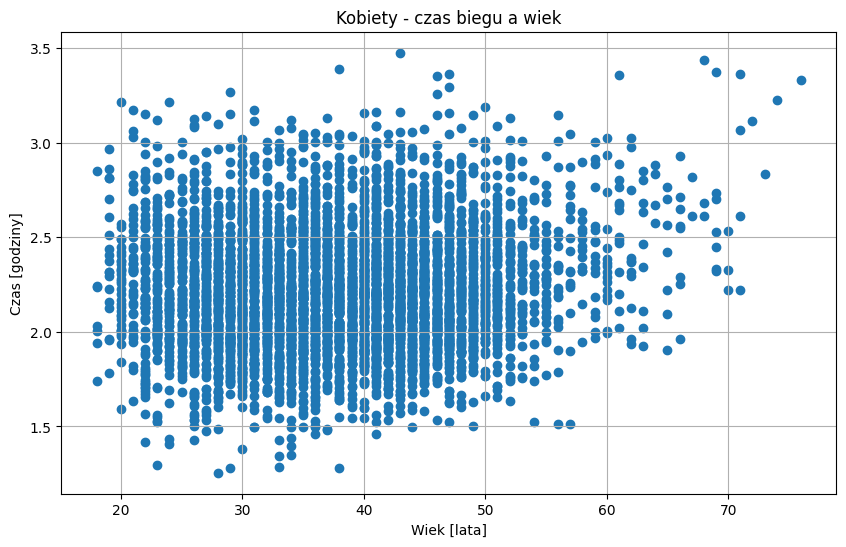

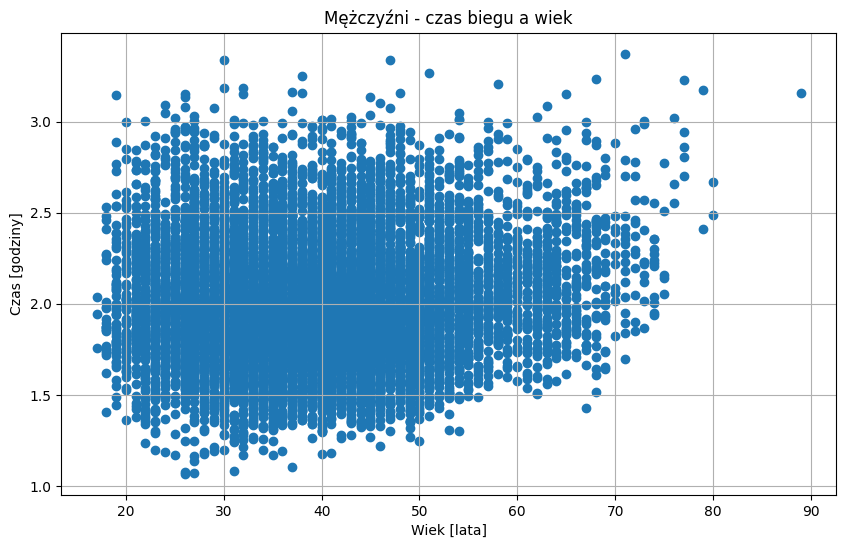

In [68]:
# sprawdzę na wykresie zależności czasów od wieku i płci biegacza, aby ocenić czy dotychczasowe
# przetwarzanie wyeliminowało wartości odstające
df_2["Czas_godziny"] = df_2["Czas"] / 3600
import matplotlib.pyplot as plt

# Kobiety
df_k = df_2[df_2["Płeć"] == "K"]

plt.figure(figsize=(10, 6))
plt.scatter(df_k["Wiek_w_latach"], df_k["Czas_godziny"])
plt.xlabel("Wiek [lata]")
plt.ylabel("Czas [godziny]")
plt.title("Kobiety - czas biegu a wiek")
plt.grid(True)
plt.show()

# Mężczyźni
df_m = df_2[df_2["Płeć"] == "M"]

plt.figure(figsize=(10, 6))
plt.scatter(df_m["Wiek_w_latach"], df_m["Czas_godziny"])
plt.xlabel("Wiek [lata]")
plt.ylabel("Czas [godziny]")
plt.title("Mężczyźni - czas biegu a wiek")
plt.grid(True)
plt.show()

In [87]:
import pandas as pd

df_corr = df_2.copy()

# Kodowanie płci
df_corr["Płeć_num"] = df_corr["Płeć"].map({
    "K": 0,
    "M": 1
})

df_corr

,Płeć,Rocznik,5 km Czas,Czas,Wiek_w_latach,Czas_godziny,Płeć_num
0,M,1992.0,877.0,3899.0,31.0,1.083056,1
1,M,1986.0,888.0,3983.0,37.0,1.106389,1
2,M,1996.0,946.0,4104.0,27.0,1.140000,1
3,M,1988.0,971.0,4216.0,35.0,1.171111,1
4,M,1995.0,972.0,4227.0,28.0,1.174167,1
...,...,...,...,...,...,...,...
19244,K,1977.0,2396.0,11866.0,47.0,3.296111,0
19245,K,1948.0,2610.0,11987.0,76.0,3.329722,0
19246,K,1978.0,2526.0,12068.0,46.0,3.352222,0
19247,K,1955.0,2960.0,12138.0,69.0,3.371667,0


In [88]:
kolumny = [
    "Płeć_num",
    "5 km Czas",
    "Wiek_w_latach",
    "Czas"
]

corr_matrix = df_corr[kolumny].corr()

print(corr_matrix)

               Płeć_num  5 km Czas  Wiek_w_latach      Czas
Płeć_num       1.000000  -0.339925       0.078303 -0.314381
5 km Czas     -0.339925   1.000000       0.057359  0.936961
Wiek_w_latach  0.078303   0.057359       1.000000  0.065923
Czas          -0.314381   0.936961       0.065923  1.000000


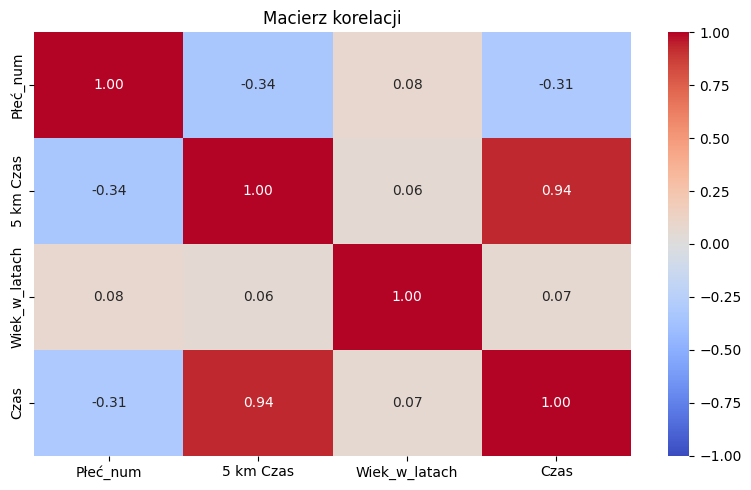

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1)

plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()

In [100]:
kolumny = ["Płeć_num","5 km Czas","Wiek_w_latach","Czas"]
df_fin=df_corr[kolumny]
df_fin

,Płeć_num,5 km Czas,Wiek_w_latach,Czas
0,1,877.0,31.0,3899.0
1,1,888.0,37.0,3983.0
2,1,946.0,27.0,4104.0
3,1,971.0,35.0,4216.0
4,1,972.0,28.0,4227.0
...,...,...,...,...
19244,0,2396.0,47.0,11866.0
19245,0,2610.0,76.0,11987.0
19246,0,2526.0,46.0,12068.0
19247,0,2960.0,69.0,12138.0


In [103]:
#from pycaret.classification import setup, compare_models, finalize_model, plot_model, save_model
from pycaret.regression import setup, compare_models, finalize_model, plot_model, save_model
#from pycaret.datasets import get_data
#pip install ydata-profiling

In [104]:
#get_data("juice", profile=False)
#kolumny = ["Płeć_num","5 km Czas","Wiek_w_latach","Czas"]
df_fin

,Płeć_num,5 km Czas,Wiek_w_latach,Czas
0,1,877.0,31.0,3899.0
1,1,888.0,37.0,3983.0
2,1,946.0,27.0,4104.0
3,1,971.0,35.0,4216.0
4,1,972.0,28.0,4227.0
...,...,...,...,...
19244,0,2396.0,47.0,11866.0
19245,0,2610.0,76.0,11987.0
19246,0,2526.0,46.0,12068.0
19247,0,2960.0,69.0,12138.0


In [106]:
setup(
    data=df_fin,
    target='Czas',
    session_id=123,
    normalize=True,
    transformation=True,
    verbose=False
)

## Compare Models

In [107]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,297.8709,168910.5221,410.7815,0.8845,0.0518,0.0389,0.4410
lightgbm,Light Gradient Boosting Machine,299.8228,170157.2505,412.2462,0.8836,0.0521,0.0392,0.3020
llar,Lasso Least Angle Regression,313.5305,182471.5219,426.7948,0.8753,0.0544,0.0414,0.0650
lasso,Lasso Regression,313.5304,182471.6125,426.7949,0.8753,0.0544,0.0414,0.0690
lr,Linear Regression,313.5535,182480.5344,426.8046,0.8752,0.0544,0.0414,1.0950
ridge,Ridge Regression,313.5490,182480.4141,426.8045,0.8752,0.0544,0.0414,0.0700
lar,Least Angle Regression,313.5534,182480.5281,426.8046,0.8752,0.0544,0.0414,0.0720
omp,Orthogonal Matching Pursuit,313.7482,182540.8453,426.8804,0.8752,0.0544,0.0414,0.0660
br,Bayesian Ridge,313.5515,182480.4812,426.8045,0.8752,0.0544,0.0414,0.0750
huber,Huber Regressor,308.2714,185927.3139,430.8049,0.8729,0.0544,0.0403,0.0800


## Evaluate Models

In [110]:
final_model = finalize_model(best_model)
save_model(final_model, 'h_marathon_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Płeć_num', '5 km Czas',
                                              'Wiek_w_latach'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None, include=[],
                                     tra...
                                            criterion='friedman_mse', init=None,
            